# Titanic Exploratory Data Analysis (EDA)

This notebook performs an in-depth exploratory data analysis (EDA) on the Titanic dataset. We investigate factors affecting survival and extract key insights using visualisations and statistical summaries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

## Load Dataset

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Data Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

In [5]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

## 1. Survival Factors

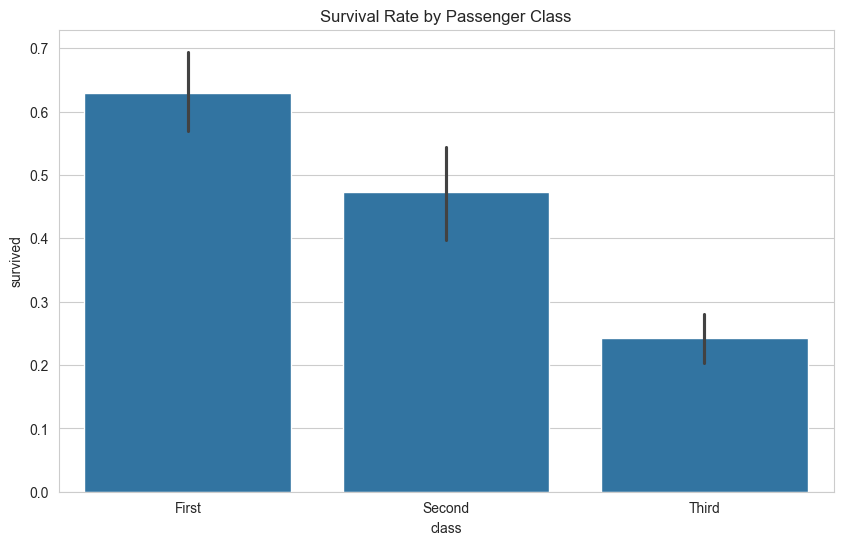

In [6]:
sns.barplot(x='class', y='survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

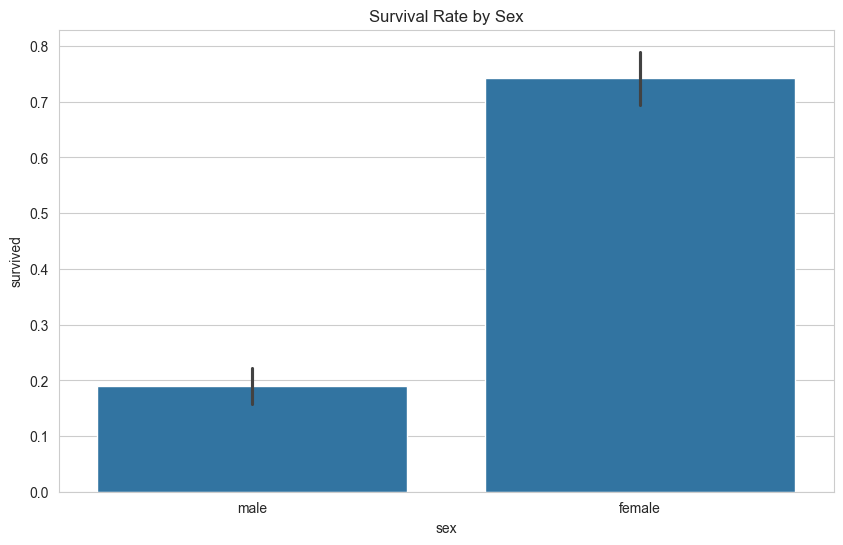

In [7]:
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

**Insight:** Sex and passenger class are the strongest individual predictors of survival. Women and first-class passengers had significantly higher survival rates.

## 2. Upper-Class Preference

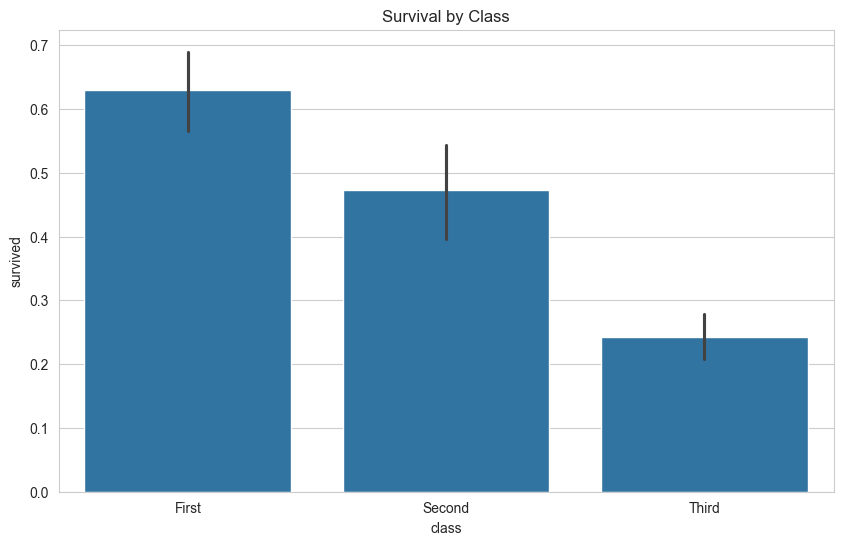

In [8]:
sns.barplot(x='class', y='survived', data=df)
plt.title('Survival by Class')
plt.show()

**Insight:** First-class passengers had a much higher survival rate, confirming socioeconomic privilege during evacuation.

## 3. Women and Children First

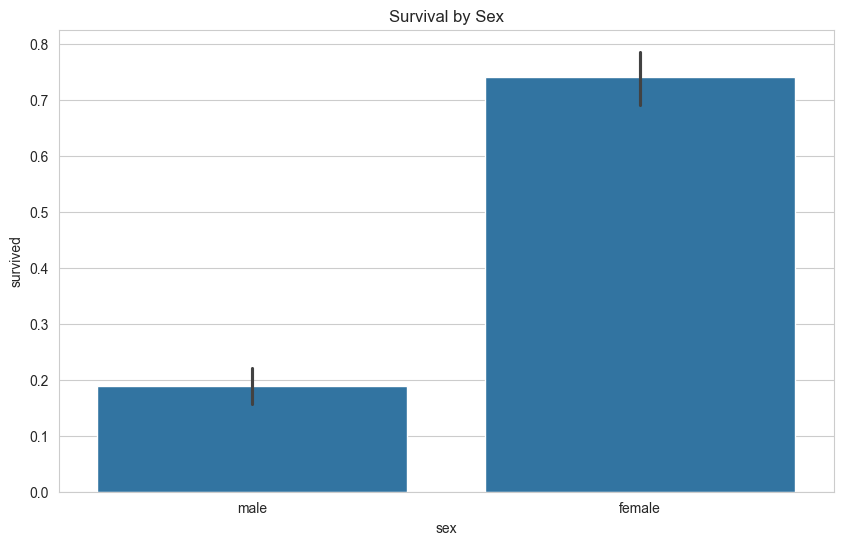

In [9]:
df['child'] = df['age'] < 16
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival by Sex')
plt.show()

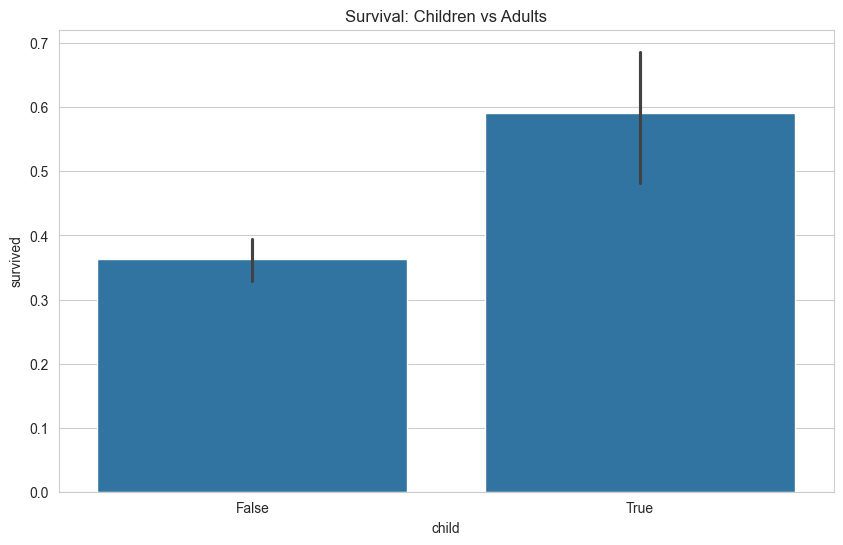

In [10]:
sns.barplot(x='child', y='survived', data=df)
plt.title('Survival: Children vs Adults')
plt.show()

**Insight:** Women and children had higher survival rates, supporting the evacuation policy of 'women and children first'.

## 4. Additional Observation

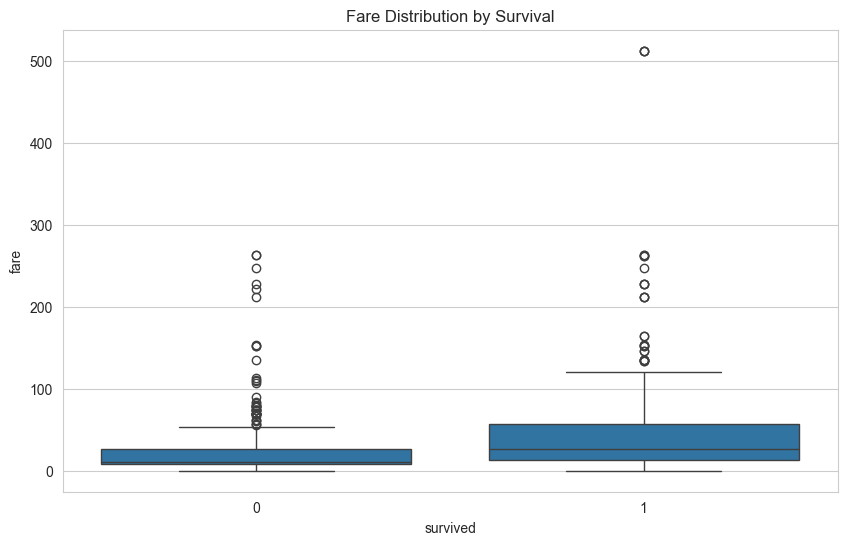

In [11]:
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Fare Distribution by Survival')
plt.show()

**Insight:** Survivors generally paid higher fares, indicating wealth influenced survival chances.

## 5. Correlation Heatmap

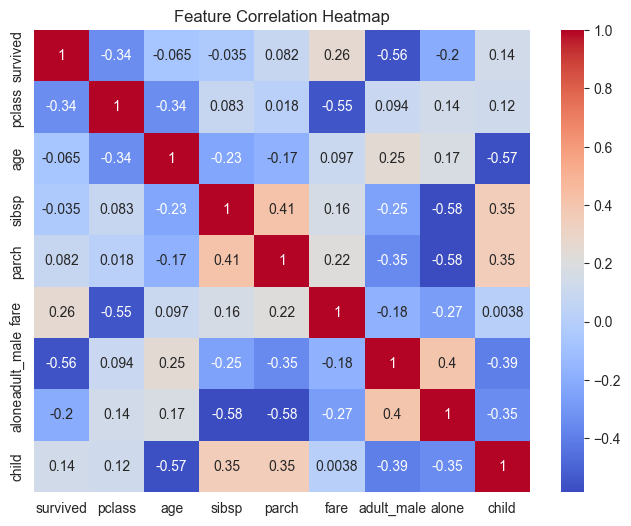

In [12]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Key Insights Summary
- Passenger class has a strong negative correlation with survival (lower class = lower survival).
- Fare shows a positive correlation with survival, reinforcing socioeconomic influence.
- Age has a weaker relationship with survival compared to class and sex.
- Sex is one of the most dominant factors affecting survival probability.

## Conclusion
Survival on the Titanic was heavily influenced by socioeconomic status, gender, and class. First-class passengers and women had significantly higher survival rates, while lower-class passengers were at a disadvantage during evacuation.